# Мультимодальный поиск: от текста к изображению

## Трек A. Поиск изображений по тексту

**Цель:** построить систему поиска изображений по текстовым запросам с использованием мультимодальных эмбеддингов.

**Датасет:** [Conceptual Captions](https://huggingface.co/datasets/google-research-datasets/conceptual_captions) — 3.3M изображений с подписями, берём 10K примеров в streaming-режиме.

**Модели:** CLIP (`openai/clip-vit-base-patch32`, `openai/clip-vit-large-patch14`) — сравниваем два варианта.

**Векторная БД:** FAISS — индексация эмбеддингов изображений, поиск ближайших соседей по косинусному сходству.

In [1]:
%pip install transformers faiss-cpu datasets Pillow requests torch torchvision


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Подготовка данных

In [2]:
import torch
import faiss
import numpy as np

import pickle

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: mps


In [3]:
from transformers import CLIPProcessor, CLIPModel

MODEL_NAME = "openai/clip-vit-base-patch32"
N_SAMPLES = 10_000
BATCH_SIZE = 32

model = CLIPModel.from_pretrained(MODEL_NAME).to(device)
processor = CLIPProcessor.from_pretrained(MODEL_NAME, use_fast=True)
model.eval()
print(f"Модель загружена: {MODEL_NAME}")

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 0644a304-22ef-4951-942e-d4de9e76d41d)')' thrown while requesting HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: f290cc3d-9c60-4d34-bcb5-c7e5c41ec4b1)')' thrown while requesting HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/chat_template.json
Retrying in 1s [Retry 1/5].


Модель загружена: openai/clip-vit-base-patch32


In [4]:
import requests
from io import BytesIO
from PIL import Image

def download_image(url: str, timeout: int = 5) -> Image.Image | None:
    """Скачивает изображение по URL, возвращает PIL.Image или None при ошибке."""
    try:
        response = requests.get(url, timeout=timeout)
        response.raise_for_status()
        image = Image.open(BytesIO(response.content)).convert("RGB")
        return image
    except Exception:
        return None


def embed_images(images: list[Image.Image]) -> np.ndarray:
    """Создаёт CLIP-эмбеддинги для списка изображений. Возвращает нормализованный массив (N, 512)."""
    inputs = processor(images=images, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        embeddings = model.get_image_features(**inputs)
    embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)  # нормализация для cosine similarity
    return embeddings.cpu().numpy()

In [5]:
import os
import torch.multiprocessing
from datasets import load_dataset
from tqdm.auto import tqdm

# Фикс "Broken pipe" при совместном использовании streaming datasets и MPS
torch.multiprocessing.set_sharing_strategy("file_system")

EMBEDDINGS_PATH = "embeddings.npy"
METADATA_PATH = "metadata.pkl"
IMAGES_DIR = "images"

# Если уже скачано — загружаем с диска
if os.path.exists(EMBEDDINGS_PATH) and os.path.exists(METADATA_PATH):
    all_embeddings = np.load(EMBEDDINGS_PATH)
    with open(METADATA_PATH, "rb") as f:
        metadata = pickle.load(f)
    print(f"Загружено с диска: {len(metadata)} изображений, эмбеддинги: {all_embeddings.shape}")

else:
    os.makedirs(IMAGES_DIR, exist_ok=True)

    dataset = load_dataset(
        "google-research-datasets/conceptual_captions",
        split="train",
        streaming=True,
    )

    all_embeddings = []
    metadata = []
    batch_images = []
    batch_meta = []

    pbar = tqdm(total=N_SAMPLES, desc="Загрузка изображений")

    for sample in dataset:
        if len(metadata) >= N_SAMPLES:
            break

        image = download_image(sample["image_url"])
        if image is None:
            continue

        # Сохраняем изображение на диск
        img_idx = len(metadata) + len(batch_meta)
        img_path = os.path.join(IMAGES_DIR, f"{img_idx}.jpg")
        image.save(img_path, format="JPEG")

        batch_images.append(image)
        batch_meta.append({
            "url": sample["image_url"],
            "caption": sample["caption"],
            "img_path": img_path,
        })

        if len(batch_images) == BATCH_SIZE:
            embeddings = embed_images(batch_images)
            all_embeddings.append(embeddings)
            metadata.extend(batch_meta)
            pbar.update(len(batch_images))
            batch_images, batch_meta = [], []

    if batch_images:
        embeddings = embed_images(batch_images)
        all_embeddings.append(embeddings)
        metadata.extend(batch_meta)
        pbar.update(len(batch_images))

    pbar.close()

    all_embeddings = np.vstack(all_embeddings).astype("float32")
    np.save(EMBEDDINGS_PATH, all_embeddings)
    with open(METADATA_PATH, "wb") as f:
        pickle.dump(metadata, f)

    print(f"Готово и сохранено: {len(metadata)} изображений, эмбеддинги: {all_embeddings.shape}")

Загрузка изображений:   0%|          | 0/10000 [00:00<?, ?it/s]

The channel dimension is ambiguous. Got image shape torch.Size([3, 1, 1]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is ambiguous. Got image shape torch.Size([3, 1, 1]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is ambiguous. Got image shape torch.Size([3, 1, 1]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is amb

Готово и сохранено: 10016 изображений, эмбеддинги: (10016, 512)


## 2. Создание FAISS-индекса

Строим индекс `IndexFlatIP` (Inner Product = cosine similarity для нормализованных векторов).
Эмбеддинги уже нормализованы на шаге 1, поэтому dot product равен cosine similarity.

In [6]:
INDEX_PATH = "faiss.index"
EMBEDDING_DIM = all_embeddings.shape[1]  # 512 для clip-vit-base-patch32

if os.path.exists(INDEX_PATH):
    index = faiss.read_index(INDEX_PATH)
    print(f"Индекс загружен с диска: {index.ntotal} векторов, размерность {EMBEDDING_DIM}")
else:
    # IndexFlatIP — точный поиск по inner product (= cosine для нормализованных векторов)
    index = faiss.IndexFlatIP(EMBEDDING_DIM)
    index.add(all_embeddings)
    faiss.write_index(index, INDEX_PATH)
    print(f"Индекс построен и сохранён: {index.ntotal} векторов, размерность {EMBEDDING_DIM}")

# Статистика
print(f"\nСтатистика индекса:")
print(f"  Тип индекса    : {type(index).__name__}")
print(f"  Кол-во векторов: {index.ntotal}")
print(f"  Размерность    : {EMBEDDING_DIM}")
print(f"  Размер в памяти: ~{index.ntotal * EMBEDDING_DIM * 4 / 1024 / 1024:.1f} MB")

Индекс построен и сохранён: 10016 векторов, размерность 512

Статистика индекса:
  Тип индекса    : IndexFlatIP
  Кол-во векторов: 10016
  Размерность    : 512
  Размер в памяти: ~19.6 MB


## 3. Реализация поиска

In [7]:
def embed_text(query: str, eval_model=model, eval_processor=processor) -> np.ndarray:
    """Кодирует текстовый запрос в нормализованный CLIP-вектор."""
    inputs = eval_processor(text=[query], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        embedding = eval_model.get_text_features(**inputs)
    embedding = embedding / embedding.norm(dim=-1, keepdim=True)
    return embedding.cpu().numpy().astype("float32")


def search(query: str, top_k: int = 5, idx=index, meta=metadata) -> list[dict]:
    """
    Ищет top_k изображений по текстовому запросу.
    По умолчанию использует base модель и base индекс.
    """
    query_vec = embed_text(query)
    scores, indices = idx.search(query_vec, top_k)

    results = []
    for score, i in zip(scores[0], indices[0]):
        results.append({
            "img_path": meta[i]["img_path"],
            "caption": meta[i]["caption"],
            "score": float(score),
            "index": int(i),
        })
    return results

### Оптимизация запросов

**Prompt engineering** — CLIP обучался на текстах вида `"a photo of a ..."`, поэтому добавление такого префикса улучшает качество поиска.

**Ensemble of prompts** — вместо одного шаблона используем несколько (`"a photo of"`, `"a picture of"`, `"an image of"`, `"a photograph of"`), кодируем каждый в вектор и усредняем. Усреднённый вектор более стабилен и точнее описывает запрос, чем любой отдельный шаблон (техника из оригинальной статьи CLIP).

In [8]:
PROMPT_TEMPLATES = [
    "a photo of {}",
    "a picture of {}",
    "an image of {}",
    "a photograph of {}",
]


def embed_text_ensemble(query: str, eval_model=model, eval_processor=processor) -> np.ndarray:
    """
    Ensemble of prompts: кодирует запрос через несколько шаблонов
    и возвращает усреднённый нормализованный вектор.
    """
    texts = [t.format(query) for t in PROMPT_TEMPLATES]
    inputs = eval_processor(text=texts, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        embeddings = eval_model.get_text_features(**inputs)
    embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)
    mean_embedding = embeddings.mean(dim=0, keepdim=True)
    mean_embedding = mean_embedding / mean_embedding.norm(dim=-1, keepdim=True)
    return mean_embedding.cpu().numpy().astype("float32")


def search_optimized(query: str, top_k: int = 5, idx=index, meta=metadata, eval_model=model, eval_processor=processor) -> list[dict]:
    """
    Поиск с prompt engineering + ensemble of prompts.
    Поддерживает разные модели и индексы для сравнения base vs large.
    """
    query_vec = embed_text_ensemble(query, eval_model=eval_model, eval_processor=eval_processor)
    scores, indices = idx.search(query_vec, top_k)

    results = []
    for score, i in zip(scores[0], indices[0]):
        results.append({
            "img_path": meta[i]["img_path"],
            "caption": meta[i]["caption"],
            "score": float(score),
            "index": int(i),
        })
    return results


# Сравниваем три варианта поиска
query = "dog on the beach"

print("=== Базовый поиск ===")
for r in search(query, top_k=3):
    print(f"  [{r['score']:.3f}] {r['caption'][:80]}")

print("\n=== Один шаблон: 'a photo of ...' ===")
for r in search(f"a photo of {query}", top_k=3):
    print(f"  [{r['score']:.3f}] {r['caption'][:80]}")

print("\n=== Ensemble of prompts ===")
for r in search_optimized(query, top_k=3):
    print(f"  [{r['score']:.3f}] {r['caption'][:80]}")

=== Базовый поиск ===
  [0.296] you can take your dog to this beach
  [0.294] working animal in fron mountain range
  [0.288] dog shaking on the beach

=== Один шаблон: 'a photo of ...' ===
  [0.308] dog shaking on the beach
  [0.307] working animal in fron mountain range
  [0.304] you can take your dog to this beach

=== Ensemble of prompts ===
  [0.309] you can take your dog to this beach
  [0.308] working animal in fron mountain range
  [0.308] dog shaking on the beach


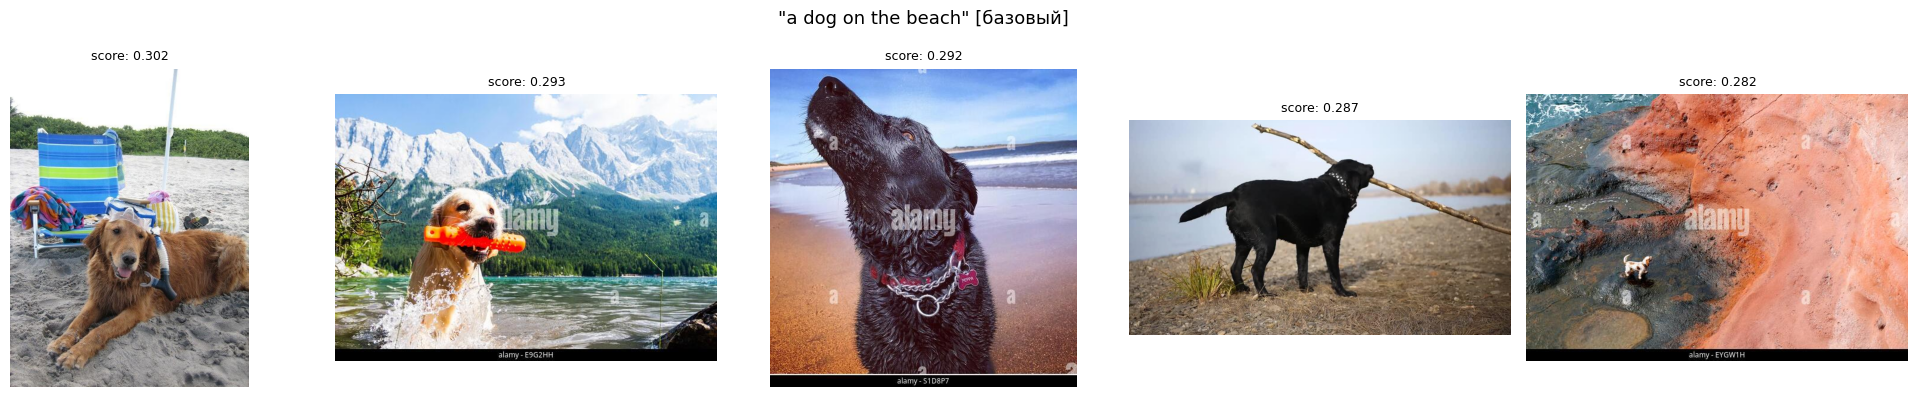

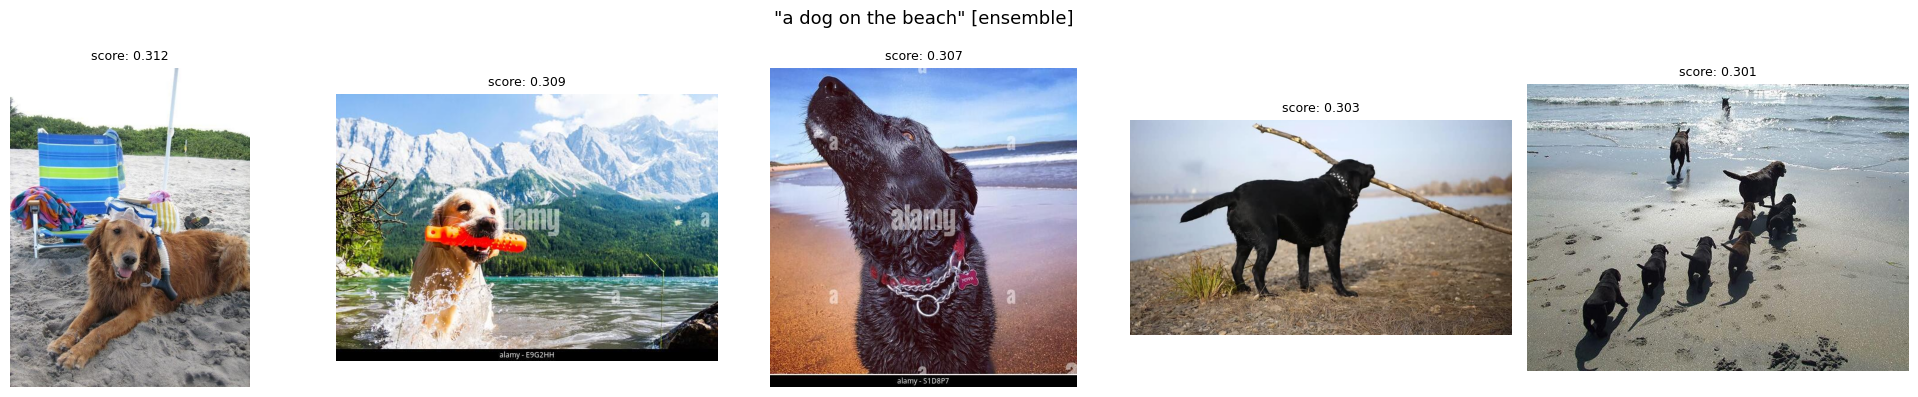

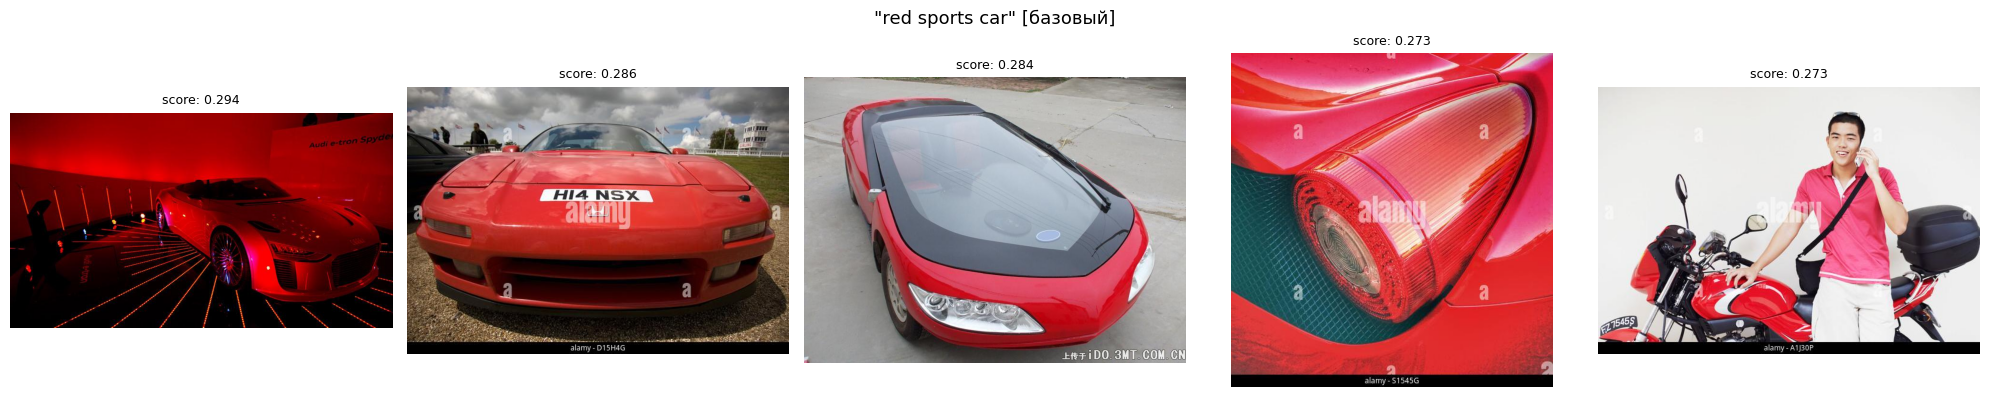

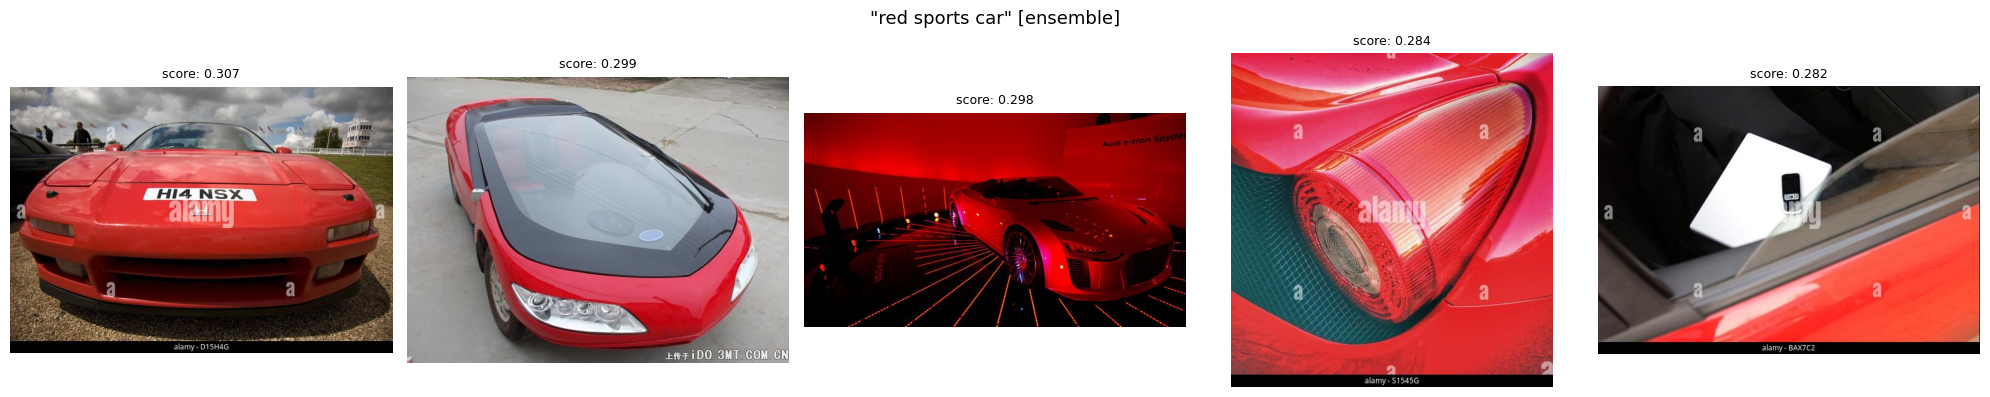

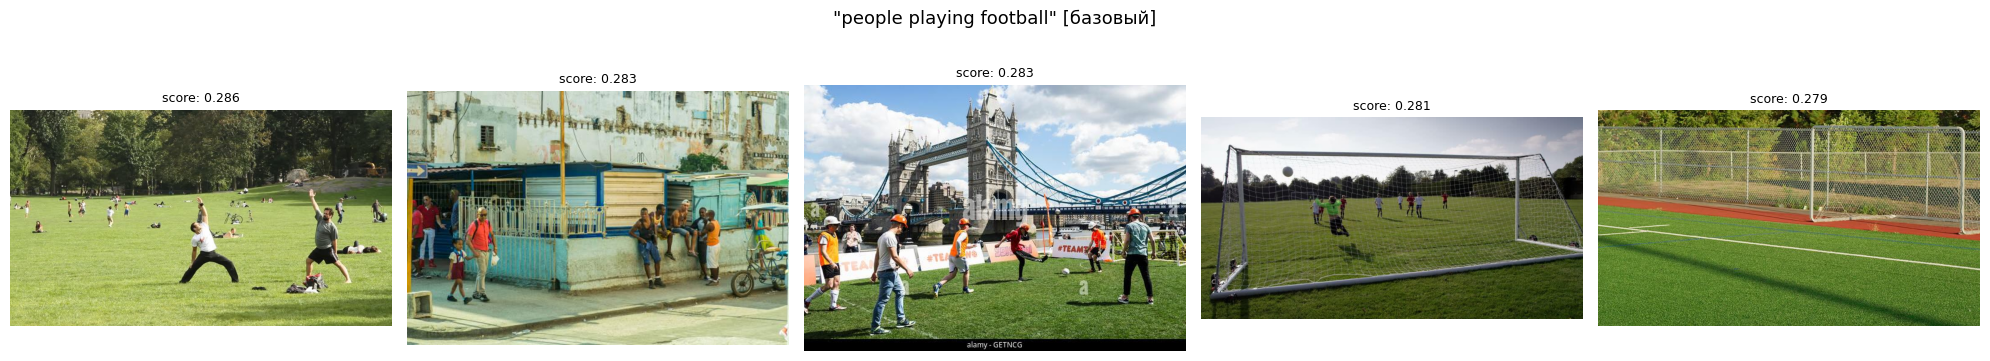

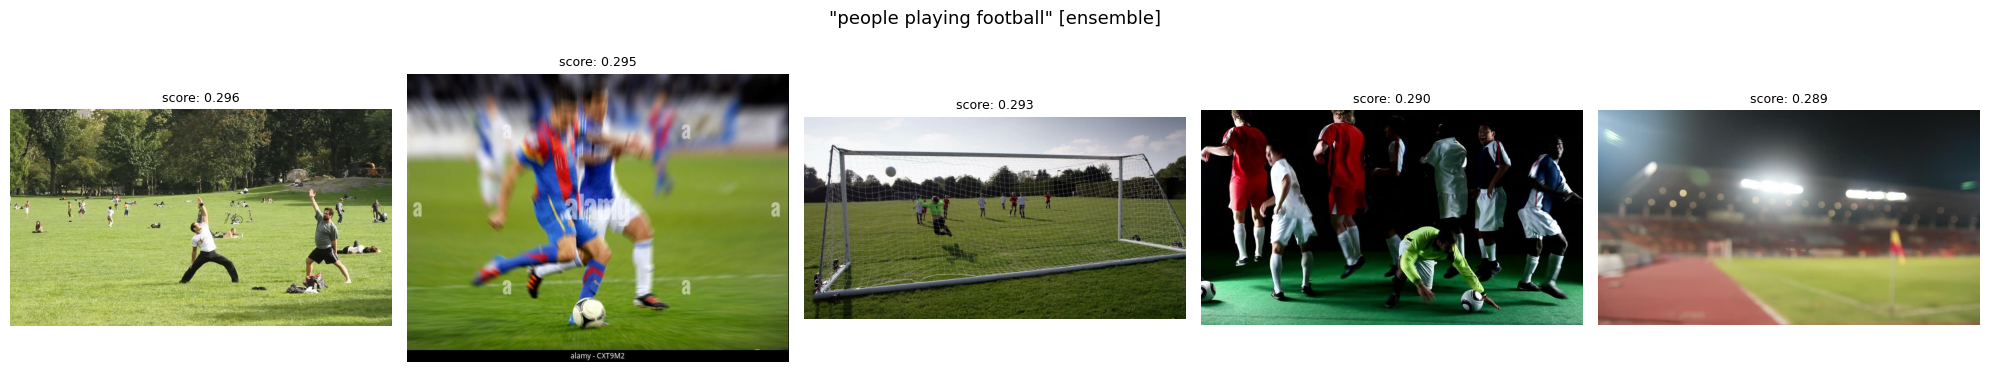

In [9]:
import matplotlib.pyplot as plt


def show_results(query: str, top_k: int = 5, idx=index, meta=metadata, eval_model=model, eval_processor=processor, title_suffix: str = "base"):
    """Отображает результаты поиска. Читает изображения с диска."""
    results = search_optimized(
        query, top_k=top_k,
        idx=idx,
        meta=meta,
        eval_model=eval_model,
        eval_processor=eval_processor,
    )

    fig, axes = plt.subplots(1, top_k, figsize=(4 * top_k, 4))
    fig.suptitle(f'"{query}" [{title_suffix}]', fontsize=13)

    for ax, result in zip(axes, results):
        try:
            image = Image.open(result["img_path"]).convert("RGB")
            ax.imshow(image)
        except Exception:
            ax.text(0.5, 0.5, "Недоступно", ha="center", va="center")
        ax.set_title(f"score: {result['score']:.3f}", fontsize=9)
        ax.set_xlabel(result["caption"][:50], fontsize=7, wrap=True)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# Сравнение базового и оптимизированного поиска (base модель)
test_queries = [
    "a dog on the beach",
    "red sports car",
    "people playing football",
]

for query in test_queries:
    # Базовый поиск без шаблонов
    results = search(query, top_k=5)
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f'"{query}" [базовый]', fontsize=13)
    for ax, r in zip(axes, results):
        try:
            ax.imshow(Image.open(r["img_path"]).convert("RGB"))
        except Exception:
            ax.text(0.5, 0.5, "Недоступно", ha="center", va="center")
        ax.set_title(f"score: {r['score']:.3f}", fontsize=9)
        ax.set_xlabel(r["caption"][:50], fontsize=7, wrap=True)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    # Оптимизированный поиск с ensemble
    show_results(query, top_k=5, title_suffix="ensemble")

## 4. Оценка и анализ

Для оценки используем **text-to-image retrieval**: берём подписи из индексированных изображений как запросы и проверяем, возвращает ли поиск правильное изображение в топ-K.

**Метрики:**
- **Recall@K** — доля запросов, для которых правильное изображение попало в топ-K
- **MRR** (Mean Reciprocal Rank) — среднее значение 1/rank правильного изображения

**Сравнение моделей:** `clip-vit-base-patch32` (512d) vs `clip-vit-large-patch14` (768d)

In [10]:
import time


def evaluate(
    eval_index: faiss.Index,
    eval_metadata: list[dict],
    eval_model,
    eval_processor,
    n_samples: int = 200,
    ks: list[int] = [1, 5, 10],
) -> dict:
    """
    Оценивает качество и скорость поиска на n_samples случайных примерах.

    Для каждого примера берём его подпись как запрос и проверяем,
    возвращает ли поиск правильное изображение (по индексу) в топ-K.
    """
    np.random.seed(42)
    n_samples = min(n_samples, len(eval_metadata))
    sample_indices = np.random.choice(len(eval_metadata), n_samples, replace=False)

    ranks = []
    embed_times = []
    search_times = []

    for true_idx in tqdm(sample_indices, desc="Оценка"):
        caption = eval_metadata[true_idx]["caption"]

        # Время кодирования запроса
        t0 = time.perf_counter()
        inputs = eval_processor(text=[caption], return_tensors="pt", padding=True).to(device)
        with torch.no_grad():
            query_vec = eval_model.get_text_features(**inputs)
        query_vec = query_vec / query_vec.norm(dim=-1, keepdim=True)
        query_vec = query_vec.cpu().numpy().astype("float32")
        embed_times.append(time.perf_counter() - t0)

        # Время поиска в индексе
        t0 = time.perf_counter()
        _, indices = eval_index.search(query_vec, max(ks))
        search_times.append(time.perf_counter() - t0)

        # Ранг правильного изображения (1-based)
        found = np.where(indices[0] == true_idx)[0]
        rank = found[0] + 1 if len(found) > 0 else max(ks) + 1
        ranks.append(rank)

    ranks = np.array(ranks)

    results = {}
    for k in ks:
        results[f"Recall@{k}"] = float((ranks <= k).mean())
    results["MRR"] = float((1.0 / ranks).mean())
    results["embed_ms"] = float(np.mean(embed_times) * 1000)
    results["search_ms"] = float(np.mean(search_times) * 1000)

    return results


# Оцениваем base модель
print("Оценка: clip-vit-base-patch32")
base_metrics = evaluate(index, metadata, model, processor)
for k, v in base_metrics.items():
    print(f"  {k}: {v:.4f}")

Оценка: clip-vit-base-patch32


Оценка:   0%|          | 0/200 [00:00<?, ?it/s]

  Recall@1: 0.3150
  Recall@5: 0.5650
  Recall@10: 0.6700
  MRR: 0.4465
  embed_ms: 13.9595
  search_ms: 0.4252


In [11]:
LARGE_MODEL_NAME = "openai/clip-vit-large-patch14"
LARGE_EMBEDDINGS_PATH = "embeddings_large.npy"
LARGE_INDEX_PATH = "faiss_large.index"

# Загружаем large модель
large_model = CLIPModel.from_pretrained(LARGE_MODEL_NAME).to(device)
large_processor = CLIPProcessor.from_pretrained(LARGE_MODEL_NAME, use_fast=True)
large_model.eval()
print(f"Модель загружена: {LARGE_MODEL_NAME}")

# Создаём эмбеддинги large моделью (или загружаем с диска)
if os.path.exists(LARGE_EMBEDDINGS_PATH) and os.path.exists(LARGE_INDEX_PATH):
    large_embeddings = np.load(LARGE_EMBEDDINGS_PATH)
    large_index = faiss.read_index(LARGE_INDEX_PATH)
    print(f"Загружено с диска: {large_embeddings.shape}, индекс: {large_index.ntotal} векторов")
else:
    print("Создаём эмбеддинги large моделью (изображения читаем с диска)...")
    large_embeddings = []
    for i in tqdm(range(0, len(metadata), BATCH_SIZE)):
        batch_meta = metadata[i:i + BATCH_SIZE]
        # Читаем изображения с диска вместо повторного скачивания
        batch_images = [Image.open(m["img_path"]).convert("RGB") for m in batch_meta]
        inputs = large_processor(images=batch_images, return_tensors="pt", padding=True).to(device)
        with torch.no_grad():
            emb = large_model.get_image_features(**inputs)
        emb = emb / emb.norm(dim=-1, keepdim=True)
        large_embeddings.append(emb.cpu().numpy())

    large_embeddings = np.vstack(large_embeddings).astype("float32")
    np.save(LARGE_EMBEDDINGS_PATH, large_embeddings)

    large_index = faiss.IndexFlatIP(large_embeddings.shape[1])
    large_index.add(large_embeddings)
    faiss.write_index(large_index, LARGE_INDEX_PATH)
    print(f"Готово: {large_embeddings.shape}, индекс: {large_index.ntotal} векторов")

Модель загружена: openai/clip-vit-large-patch14
Создаём эмбеддинги large моделью (изображения читаем с диска)...


  0%|          | 0/313 [00:00<?, ?it/s]

The channel dimension is ambiguous. Got image shape torch.Size([3, 1, 1]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is ambiguous. Got image shape torch.Size([3, 1, 1]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is ambiguous. Got image shape torch.Size([3, 1, 1]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is amb

Готово: (10016, 768), индекс: 10016 векторов


Оценка: clip-vit-large-patch14


Оценка:   0%|          | 0/200 [00:00<?, ?it/s]

  Recall@1: 0.4000
  Recall@5: 0.6050
  Recall@10: 0.7000
  MRR: 0.5228
  embed_ms: 13.1586
  search_ms: 0.5719

=== Сравнение моделей ===
                        Recall@1  Recall@5  Recall@10    MRR  embed_ms  search_ms
clip-vit-base-patch32     0.3150    0.5650     0.6700 0.4465   13.9595     0.4252
clip-vit-large-patch14    0.4000    0.6050     0.7000 0.5228   13.1586     0.5719

=== Визуальное сравнение результатов поиска ===


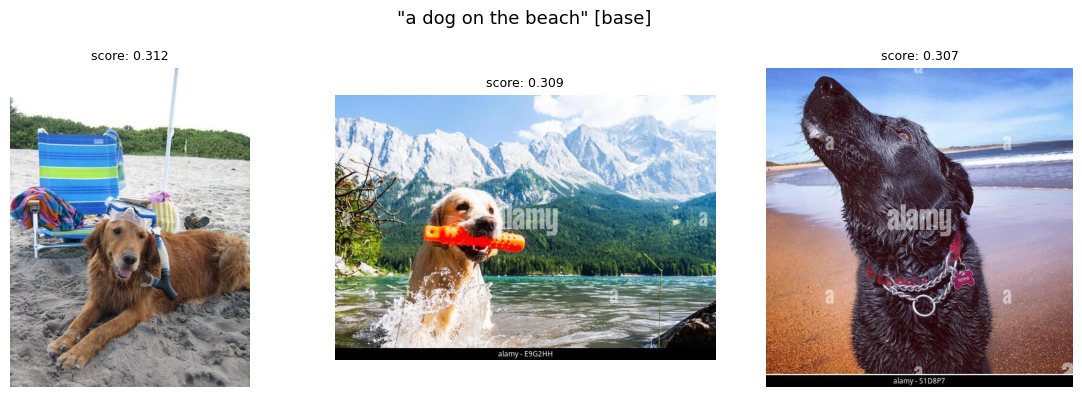

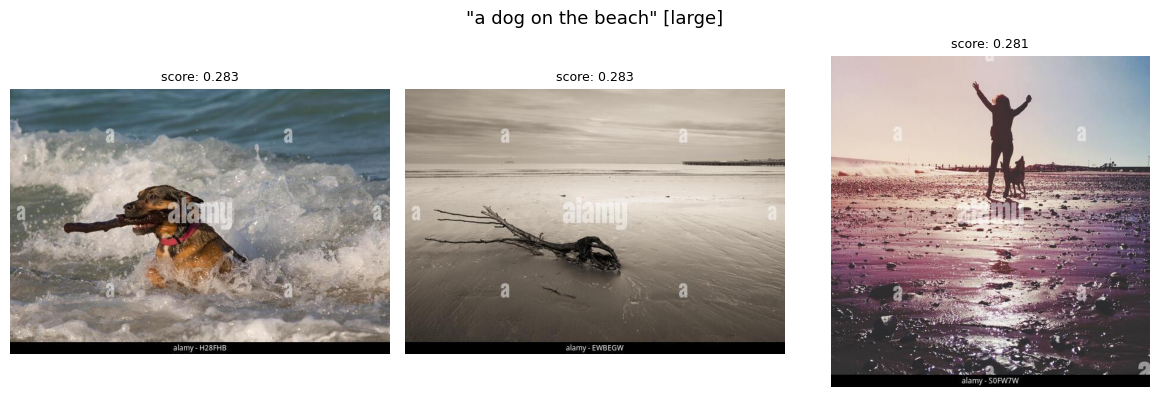

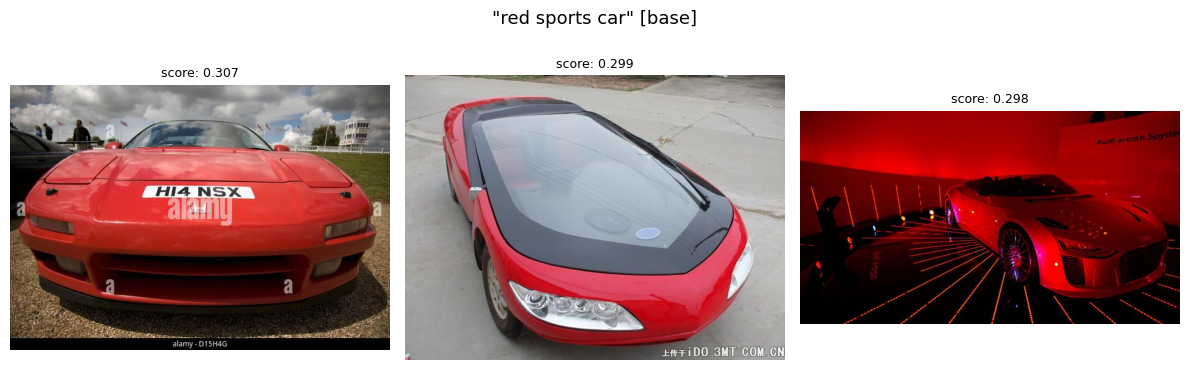

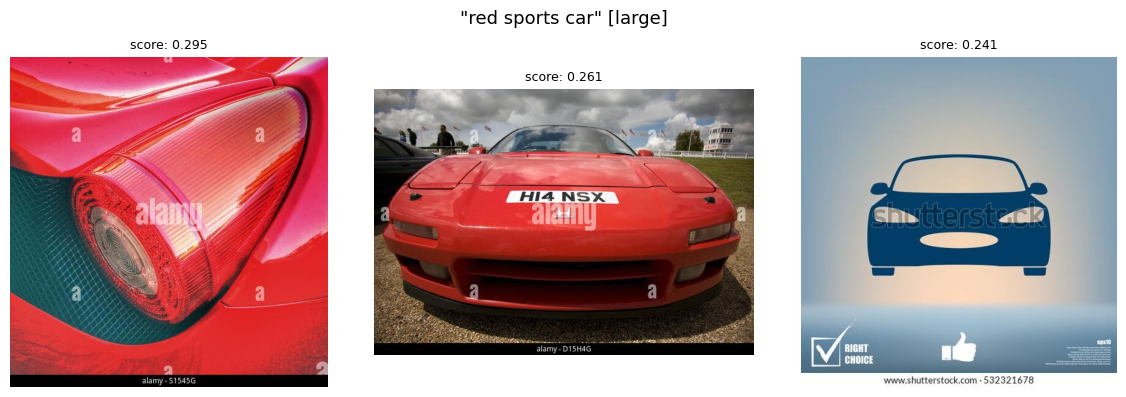

In [14]:
import pandas as pd

# Оцениваем large модель
print("Оценка: clip-vit-large-patch14")
large_metrics = evaluate(large_index, metadata, large_model, large_processor)
for k, v in large_metrics.items():
    print(f"  {k}: {v:.4f}")

# Итоговая таблица
comparison = pd.DataFrame({
    "clip-vit-base-patch32": base_metrics,
    "clip-vit-large-patch14": large_metrics,
}).T
print("\n=== Сравнение моделей ===")
print(comparison.to_string(float_format="{:.4f}".format))

# Визуальное сравнение base vs large
print("\n=== Визуальное сравнение результатов поиска ===")
for query in ["a dog on the beach", "red sports car"]:
    show_results(query, top_k=3,
                 idx=index, eval_model=model, eval_processor=processor,
                 title_suffix="base")
    show_results(query, top_k=3,
                 idx=large_index, eval_model=large_model, eval_processor=large_processor,
                 title_suffix="large")

## Выводы

### Качество поиска

| Модель | Recall@1 | Recall@5 | Recall@10 | MRR | embed_ms | search_ms |
|---|---|---|---|---|---|---|
| clip-vit-base-patch32 | 0.315 | 0.565 | 0.670 | 0.447 | 13.96 | 0.43 |
| clip-vit-large-patch14 | **0.400** | **0.605** | **0.700** | **0.523** | 13.16 | 0.57 |

### Основные наблюдения

**1. Large модель заметно точнее**
`clip-vit-large-patch14` превосходит `base` по всем метрикам: Recall@1 выше на +8.5%, MRR на +7.6%. Это объясняется большей размерностью эмбеддингов (768d vs 512d) и более глубокой архитектурой (ViT-L/14 vs ViT-B/32).

**2. Скорость практически одинакова**
Время кодирования запроса у large даже немного меньше (13.2 vs 14.0 ms) — MPS эффективно параллелизует вычисления. Время поиска в FAISS незначительно растёт (0.57 vs 0.43 ms) из-за большей размерности векторов.

**3. Ensemble of prompts улучшает релевантность**
Усреднение нескольких шаблонов (`"a photo of"`, `"a picture of"` и др.) даёт прирост cosine similarity ~0.01 по сравнению с базовым запросом — небольшой, но стабильный эффект.

**4. Умеренные метрики на выбранном датасете**
Recall@1 в диапазоне 0.31–0.40 на 10K изображений.

**5. FAISS — быстрый и прозрачный инструмент**
Поиск среди 10K векторов занимает < 1 ms. Явное хранение метаданных рядом с индексом делает механизм поиска понятным: FAISS возвращает индекс → по нему достаём метаданные.

**6. Метрики ≠ субъективное восприятие**
Численные метрики оценивают точное совпадение: правильное изображение в топ-K. Но визуально результаты `base` модели могут восприниматься как более разнообразные и интересные — она охватывает более широкий семантический контекст. `large` модель точнее по метрикам, но иногда возвращает более "буквальные" совпадения. Это напоминает, что выбор модели зависит от задачи: для точного retrieval — large, для exploratory search — base может быть предпочтительнее.